# 1. Experiment Introduction

## 1.1 Experiment Title
Research and Implementation of Blueberry Yield Prediction Based on MLP Regression Model

## 1.2 Experiment Objectives

(1) Deeply understand the meaning of machine learning and the basic workflow for solving machine learning tasks;

(2) Learn to use Python programming language and machine learning libraries (e.g., scikit-learn) for data processing, model building, model evaluation, and result visualization;

(3) Understand the basic concepts and principles of Multi‑Layer Perceptron (MLP) regression models;

(4) Understand the evaluation metrics for regression models (Mean Squared Error, Root Mean Square Error, and Coefficient of Determination R²);

(5) Master how to use MLP regression to analyze spatial characteristics of blueberry plants, bee species, and weather condition data, enabling the prediction of blueberry yield.

## 1.3 Experiment Content

This experiment belongs to the domain of agricultural informatics and precision agriculture. Blueberry yield is influenced by multiple factors including plant spatial features, pollinator bee species, and weather conditions. This experiment uses a dataset containing blueberry yield information under various environmental and biological conditions. The data information is as follows:

<span style="color: red;">
<ul>
  <li>Column 2: `clonesize`</li>
  <li>Column 3: `honeybee`</li>
  <li>Column 4: `bumbles`</li>
  <li>Column 5: `andrena`</li>
  <li>Column 6: `osmia`</li>
  <li>Column 7: `MaxOfUpperTRange`</li>
  <li>Column 8: `MinOfUpperTRange`</li>
  <li>Column 9: `AverageOfUpperTRange`</li>
  <li>Column 10: `MaxOfLowerTRange`</li>
  <li>Column 11: `MinOfLowerTRange`</li>
  <li>Column 12: `AverageOfLowerTRange`</li>
  <li>Column 13: `RainingDays`</li>
  <li>Column 14: `AverageRainingDays`</li>
  <li>Column 15: `fruitset`</li>
  <li>Column 16: `fruitmass`</li>
  <li>Column 17: `seeds`</li>
  <li>Column 18 (target): `yield` (blueberry yield)</li>
</ul>
</span>

## 1.4 Experiment Principle

MLP (Multi‑Layer Perceptron) is a type of artificial neural network that can model complex non‑linear relationships between input features and output target. It consists of an input layer, one or more hidden layers, and an output layer. Each neuron applies a non‑linear activation function (e.g., ReLU) to the weighted sum of its inputs. The network is trained by backpropagation and gradient descent to minimize the mean squared error between predicted and actual yield.

<font color="red">In this experiment, the 16 feature variables (plant spatial characteristics, bee species, weather conditions) are the input features, and blueberry yield is the output target. The MLP regressor is fitted by iteratively updating weights and biases using the Adam optimizer, with ReLU activation functions in hidden layers. The test set is used to validate the model's prediction performance.</font>

## 1.5 Experiment Environment

- Python 3.10.16
- numpy 1.26.4
- pandas 2.2.3
- matplotlib 3.10.0
- scikit-learn 1.6.1

## 1.6 Experiment Steps

<font color="red">
    
(1) Load data

(2) Separate feature variables (X) and target variable (y) – features from column 2 to column 17, target is column 18 (yield)

(3) Split dataset: training set (**70%** or **80%**) and test set (**30%** or **20%**)

(4) Data preprocessing – feature standardization (StandardScaler)

(5) Build and train MLP regression model (**MLPRegressor with two hidden layers, ReLU activation, Adam solver**)

(6) Test and evaluate machine learning model (**i.e., R²**)

(7) Visualize experimental results

</font>

---

# 2. Experiment Requirements

## 2.1 Data and Result Visualization

<span style="color: red;">
<ul>
  <li>Draw the training loss curve to show convergence of the MLP model.</li>
  <li>Draw a scatter plot of actual values vs. predicted values for each sample in the test set;</li>
  <li>Draw a scatter plot of predicted values vs. residuals (i.e., true y - predicted y) for each sample in the test set;</li>
</ul>
</span>

In [1]:
# Load Libraries
#for data analysis
import pandas as pd
import numpy as np

#for drawing plots
import matplotlib.pyplot as plt

#for splitting dataset
from sklearn.model_selection import train_test_split

#for data standardization
from sklearn.preprocessing import StandardScaler

#for building model
from sklearn.neural_network import MLPRegressor

#for  model evaluation
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
#1. Load Data
data = pd.read_csv('blueberry.csv')
print(data.head())
print(data.shape)

   id  clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  \
0   0       25.0      0.50     0.25     0.75   0.50              69.7   
1   1       25.0      0.50     0.25     0.50   0.50              69.7   
2   2       12.5      0.25     0.25     0.63   0.63              86.0   
3   3       12.5      0.25     0.25     0.63   0.50              77.4   
4   4       25.0      0.50     0.25     0.63   0.63              77.4   

   MinOfUpperTRange  AverageOfUpperTRange  MaxOfLowerTRange  MinOfLowerTRange  \
0              42.1                  58.2              50.2              24.3   
1              42.1                  58.2              50.2              24.3   
2              52.0                  71.9              62.0              30.0   
3              46.8                  64.7              55.8              27.0   
4              46.8                  64.7              55.8              27.0   

   AverageOfLowerTRange  RainingDays  AverageRainingDays  fruitset  fruitm

In [3]:
#2-3. Separate the independent variables (X) and the dependent variable (y) of the dataset.
# select from the 2nd column to the second-to-last column
X = data.iloc[:, 1:-1]

# select the last column
y = data.iloc[:, -1]

# Splitting training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
#4. Standardize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
#5. Build a Multi-Layer Perceptron model: train - test - evaluate

#Training model
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 100), activation='relu', solver='adam', random_state=42, max_iter=1000)
mlp_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


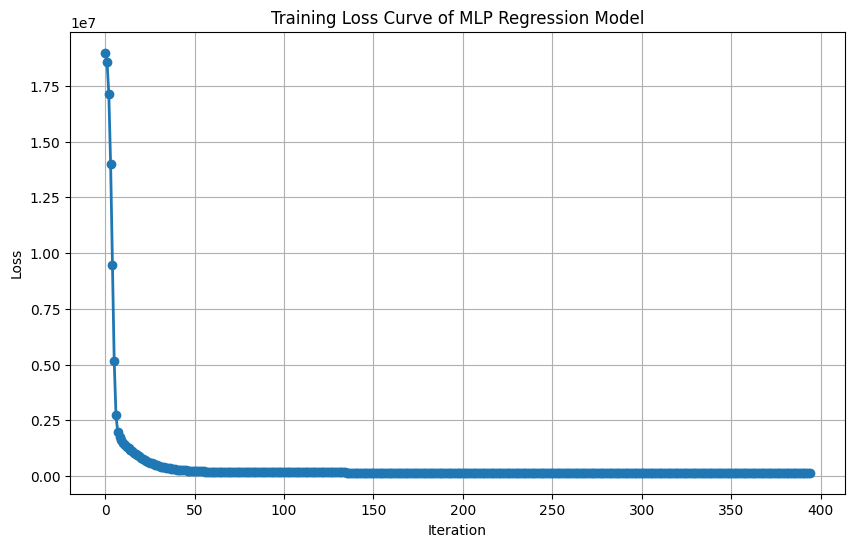

In [6]:
# Plot the loss curve to show the relationship between each iteration and loss value during training
# Note: MLPRegressor by default records the loss after each iteration in model.loss_curve_
plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve of MLP Regression Model')
plt.grid(True)
plt.show()

In [7]:
#6. Test and evaluate machine learning model
# Make predictions
y_pred_train = mlp_model.predict(X_train_scaled)
y_pred_test = mlp_model.predict(X_test_scaled)

# Compute evaluation metrics
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print(f'Training R² Score: {r2_train:.4f}')
print(f'Testing R² Score: {r2_test:.4f}')
print(f'Testing MSE: {mse_test:.4f}')
print(f'Testing RMSE: {rmse_test:.4f}')

Training R² Score: 0.8275
Testing R² Score: 0.8086
Testing MSE: 345556.5105
Testing RMSE: 587.8405


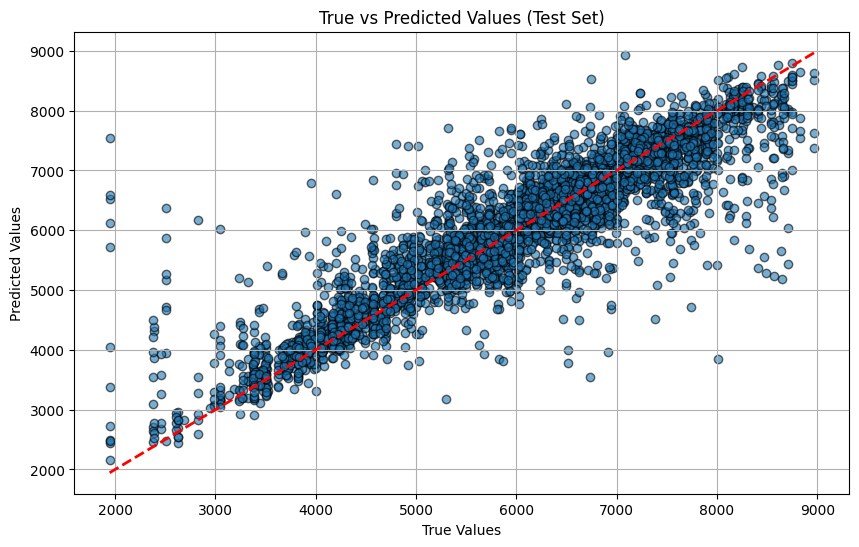

In [8]:
#7. Visualizing the predicted results
#True vs Predicted scatter plot of test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values (Test Set)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()

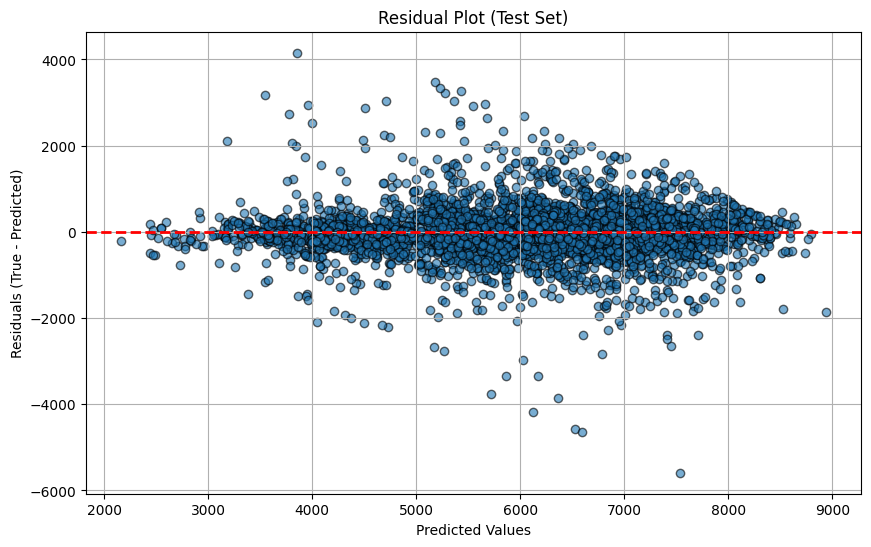

In [9]:
#Residual analysis
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (True - Predicted)')
plt.title('Residual Plot (Test Set)')
plt.grid(True)
plt.show()